In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import os
from rdkit import Chem
from rdkit.Chem import MACCSkeys, DataStructs
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score, confusion_matrix

# ==============================================================================
# 0. 核心配置与辅助函数
# ==============================================================================
# 默认配置 (你可以根据 Figure 5 的结果修改这里的 FIXED_S)
S_NEIGHBOR_THRESH = 0.8  # 计算 SLD 时定义"邻居"的阈值
EDGE_CUTOFF = 0.80        # 构建网络连线的阈值
MIN_COMMUNITY_SIZE = 2    # 过滤小社团的阈值

def get_canonical_smiles(smiles):
    try:
        if pd.isna(smiles): return None
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
    except:
        pass
    return None

def get_fps(smiles_series):
    """批量计算 MACCS 指纹"""
    fps = []
    valid_indices = []
    smiles_series = smiles_series.reset_index(drop=True)
    for idx, smi in enumerate(smiles_series):
        m = Chem.MolFromSmiles(smi)
        if m:
            fps.append(MACCSkeys.GenMACCSKeys(m))
            valid_indices.append(idx)
    return fps, valid_indices

def calculate_sld_strict(sim_row, train_y, target_y, s_thresh=0.8):
    """
    严格复刻 Chen et al. Eq(7): S_LD = (1/K) * Sum(S * D)
    """
    neighbor_idx = np.where(sim_row >= s_thresh)[0]
    if len(neighbor_idx) == 0: return 0.0 # 无邻居，视为无风险
    
    sim_vals = sim_row[neighbor_idx]
    neighbor_labels = train_y[neighbor_idx]
    
    # 活性差异 D: 异类=1, 同类=0
    diffs = np.abs(neighbor_labels - target_y)
    
    # 加权平均
    sld = np.sum(sim_vals * diffs) / len(neighbor_idx)
    return sld

def process_assay_file(filepath):
    if not os.path.exists(filepath): return pd.DataFrame()
    try:
        df = pd.read_csv(filepath)
        df = df[df['PUBCHEM_ACTIVITY_OUTCOME'].isin(['Active', 'Inactive'])].copy()
        df['label'] = df['PUBCHEM_ACTIVITY_OUTCOME'].map({'Active': 1, 'Inactive': 0})
        df['canon_smiles'] = df['SMILES'].apply(get_canonical_smiles)
        return df.dropna(subset=['canon_smiles'])[['canon_smiles', 'label']]
    except:
        return pd.DataFrame()

In [2]:
# ==============================================================================
# 1. 数据加载与融合 (Training Set)
# ==============================================================================
print(">>> 步骤 1: 构建训练集 (8 Assays + Probe)...")

assay_files = [
    "AID_1189_datatable_all.csv", "AID_1194_datatable_all.csv", 
    "AID_1199_datatable_all.csv", "AID_1205_datatable_all.csv",
    "AID_1208_datatable_all.csv", "AID_1259407_datatable_all.csv",
    "AID_1259408_datatable_all.csv", "AID_1259411_datatable_all.csv"
]

df_list = []
for f in assay_files:
    temp = process_assay_file(f)
    if not temp.empty: df_list.append(temp)

if df_list:
    df_assays = pd.concat(df_list, ignore_index=True)
    df_assays_grouped = df_assays.groupby('canon_smiles')['label'].mean().reset_index()
    df_assays_grouped['label_assay'] = (df_assays_grouped['label'] >= 0.5).astype(int)
    df_assays_grouped = df_assays_grouped.drop(columns=['label'])
else:
    df_assays_grouped = pd.DataFrame(columns=['canon_smiles', 'label_assay'])

probe_file = "probe_data.csv"
if os.path.exists(probe_file):
    df_probe = pd.read_csv(probe_file)
    df_probe['label_probe'] = df_probe['Assessment Type'].map({'Cancer': 1, 'Noncancer': 0})
    df_probe['canon_smiles'] = df_probe['SMILES'].apply(get_canonical_smiles)
    df_probe = df_probe.dropna(subset=['canon_smiles'])[['canon_smiles', 'label_probe']]
    
    df_merged = pd.merge(df_assays_grouped, df_probe, on='canon_smiles', how='outer')
    
    def resolve(row):
        if pd.notna(row['label_probe']): return int(row['label_probe'])
        elif pd.notna(row['label_assay']): return int(row['label_assay'])
        return None
    
    df_merged['final_label'] = df_merged.apply(resolve, axis=1)
    df_train = df_merged.dropna(subset=['final_label'])[['canon_smiles', 'final_label']].copy()
    df_train['final_label'] = df_train['final_label'].astype(int)
    df_train['set_type'] = 'Training'
else:
    print("Error: probe_data.csv not found.")
    df_train = pd.DataFrame()

print(f"   训练集就绪: {len(df_train)} 个化合物")

>>> 步骤 1: 构建训练集 (8 Assays + Probe)...


[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:17] WARNING: not removing hydrogen atom without neighbors
[00:44:23] WARNING: not removing hydrogen atom without neighbors
[00:44:23] WARNING: not removing hydrogen atom without neighbors
[00:44:23] WARNING: not removing hydrogen atom without neighbors
[00:44:23] WARNING: not r

   训练集就绪: 9524 个化合物


In [3]:
# ==============================================================================
# 2. 加载外部验证集 (External Set)
# ==============================================================================
print(">>> 步骤 2: 读取外部验证集...")
ext_file = "external_data.csv" 
if os.path.exists(ext_file):
    df_ext = pd.read_csv(ext_file)
    df_ext['canon_smiles'] = df_ext['smiles'].apply(get_canonical_smiles)
    # 确保 pred_prob 存在，用于画 Figure 5
    if 'pred_prob' not in df_ext.columns:
        print("警告: 外部集缺少 'pred_prob' 列，将无法绘制 Figure 5！")
        df_ext['pred_prob'] = 0.5 # 占位符
        
    df_ext = df_ext.dropna(subset=['canon_smiles', 'final_label']).reset_index(drop=True)
    df_ext['set_type'] = 'External'
    print(f"   外部集就绪: {len(df_ext)} 个化合物")
else:
    print("Error: external data.csv not found.")
    df_ext = pd.DataFrame()

>>> 步骤 2: 读取外部验证集...
   外部集就绪: 212 个化合物


In [4]:
# ==============================================================================
# 3. 计算指纹与 SLD
# ==============================================================================
print(">>> 步骤 3 & 4: 计算指纹与 SLD...")

# 3.1 指纹
train_fps, train_idx = get_fps(df_train['canon_smiles'])
df_train = df_train.iloc[train_idx].reset_index(drop=True)

ext_fps, ext_idx = get_fps(df_ext['canon_smiles'])
df_ext = df_ext.iloc[ext_idx].reset_index(drop=True)

n_train = len(train_fps)
train_y = df_train['final_label'].values

# 3.2 训练集 SLD (计算全量或抽样)
print("   计算 Training 内部 SLD...")
sim_matrix_train = np.zeros((n_train, n_train))
for i in range(n_train):
    sim_matrix_train[i, :] = DataStructs.BulkTanimotoSimilarity(train_fps[i], train_fps)

train_slds = []
for i in range(n_train):
    # 排除自己 (将自身相似度置0)
    row_sim = sim_matrix_train[i, :].copy()
    row_sim[i] = 0.0
    val = calculate_sld_strict(row_sim, train_y, target_y=train_y[i], s_thresh=S_NEIGHBOR_THRESH)
    train_slds.append(val)
df_train['SLD'] = train_slds

# 3.3 外部集 SLD (Ext vs Train)
print("   计算 External SLD...")
sim_matrix_ext_train = np.zeros((len(ext_fps), n_train))
for i in range(len(ext_fps)):
    sim_matrix_ext_train[i, :] = DataStructs.BulkTanimotoSimilarity(ext_fps[i], train_fps)

# 计算 Max_Sim (用于 Figure 5a)
df_ext['Max_Sim'] = np.max(sim_matrix_ext_train, axis=1)

# 计算 SLD (用于 Figure 5b 和 导出)
ext_slds = []
for i in range(len(ext_fps)):
    val = calculate_sld_strict(sim_matrix_ext_train[i], train_y, 
                               target_y=df_ext.iloc[i]['final_label'], 
                               s_thresh=S_NEIGHBOR_THRESH)
    ext_slds.append(val)
df_ext['SLD'] = ext_slds

>>> 步骤 3 & 4: 计算指纹与 SLD...


[00:44:36] WARNING: not removing hydrogen atom without neighbors
[00:44:39] WARNING: not removing hydrogen atom without neighbors
[00:44:39] WARNING: not removing hydrogen atom without neighbors
[00:44:39] WARNING: not removing hydrogen atom without neighbors
[00:44:39] WARNING: not removing hydrogen atom without neighbors
[00:44:40] WARNING: not removing hydrogen atom without neighbors
[00:44:40] WARNING: not removing hydrogen atom without neighbors
[00:44:40] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:42] WARNING: not removing hydrogen atom without neighbors
[00:44:45] WARNING: not r

   计算 Training 内部 SLD...
   计算 External SLD...



>>> 步骤 5: 绘制 Figure 5 (阈值优化)...


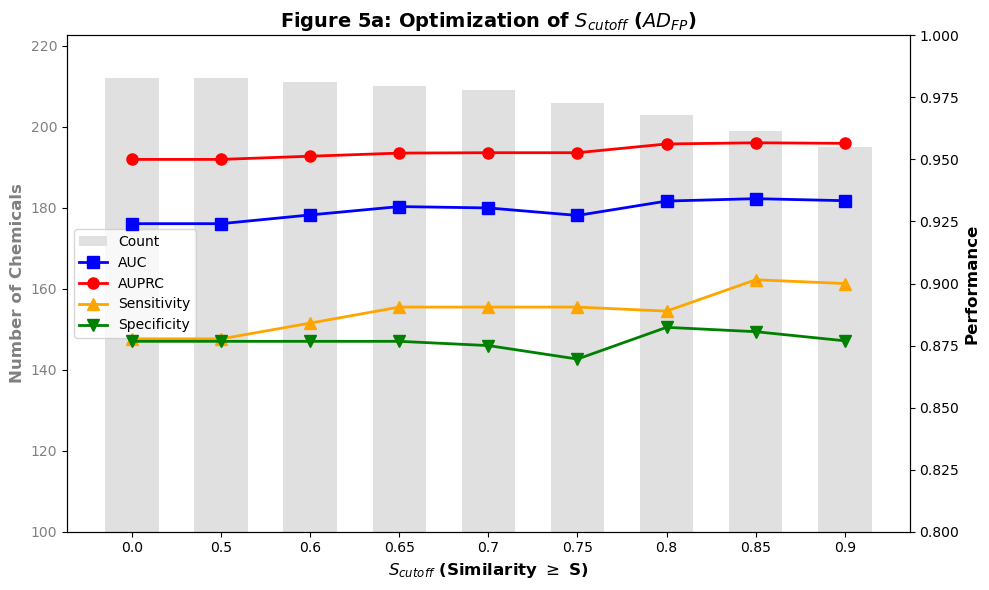

In [5]:
# ==============================================================================
# 5. 复刻 Figure 5: 阈值优化 (您提供的代码)
# ==============================================================================
print("\n>>> 步骤 5: 绘制 Figure 5 (阈值优化)...")

def evaluate_metrics(df_sub):
    if len(df_sub) < 5: return [np.nan]*4
    y_true = df_sub['final_label']
    y_prob = df_sub['pred_prob']
    y_pred = (y_prob >= 0.5).astype(int)
    try:
        auc = roc_auc_score(y_true, y_prob)
        auprc = average_precision_score(y_true, y_prob)
        sens = recall_score(y_true, y_pred, zero_division=0)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        return [auc, auprc, sens, spec]
    except:
        return [np.nan]*4

def plot_fig5(df_res, x_col, xlabel, title, y_left_min=0, y_left_max=None, y_right_min=0.0):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 左轴
    ax1.bar(df_res[x_col].astype(str), df_res['Count'], color='#e0e0e0', label='Count', width=0.6)
    ax1.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Chemicals', fontsize=12, fontweight='bold', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    if y_left_max is None: y_left_max = df_res['Count'].max() * 1.05
    ax1.set_ylim(bottom=y_left_min, top=y_left_max)
    
    # 右轴
    ax2 = ax1.twinx()
    cfgs = [('AUC','blue','s','-'), ('AUPRC','red','o','-'), 
            ('Sensitivity','orange','^','-'), ('Specificity','green','v','-')]
    lines = []
    for m, c, mk, ls in cfgs:
        if m in df_res.columns:
            l, = ax2.plot(df_res[x_col].astype(str), df_res[m], color=c, marker=mk, linestyle=ls, lw=2, markersize=8, label=m)
            lines.append(l)
    
    ax2.set_ylabel('Performance', fontsize=12, fontweight='bold')
    ax2.set_ylim(bottom=y_right_min, top=1)
    
    # 图例
    bars, _ = ax1.get_legend_handles_labels()
    ax1.legend(bars + lines, ['Count'] + [l.get_label() for l in lines], loc='center left', fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# --- Part A: 优化 S_cutoff ---
s_vals = [0.0, 0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
res_a = []
for s in s_vals:
    sub = df_ext[df_ext['Max_Sim'] >= s]
    m = evaluate_metrics(sub)
    res_a.append({'S_cutoff': s, 'Count': len(sub), 'AUC': m[0], 'AUPRC': m[1], 'Sensitivity': m[2], 'Specificity': m[3]})

plot_fig5(pd.DataFrame(res_a), 'S_cutoff', r'$S_{cutoff}$ (Similarity $\geq$ S)', 
          r'Figure 5a: Optimization of $S_{cutoff}$ ($AD_{FP}$)', y_left_min=100, y_right_min=0.8)



选定 S_cutoff = 0.8 进行第二步...


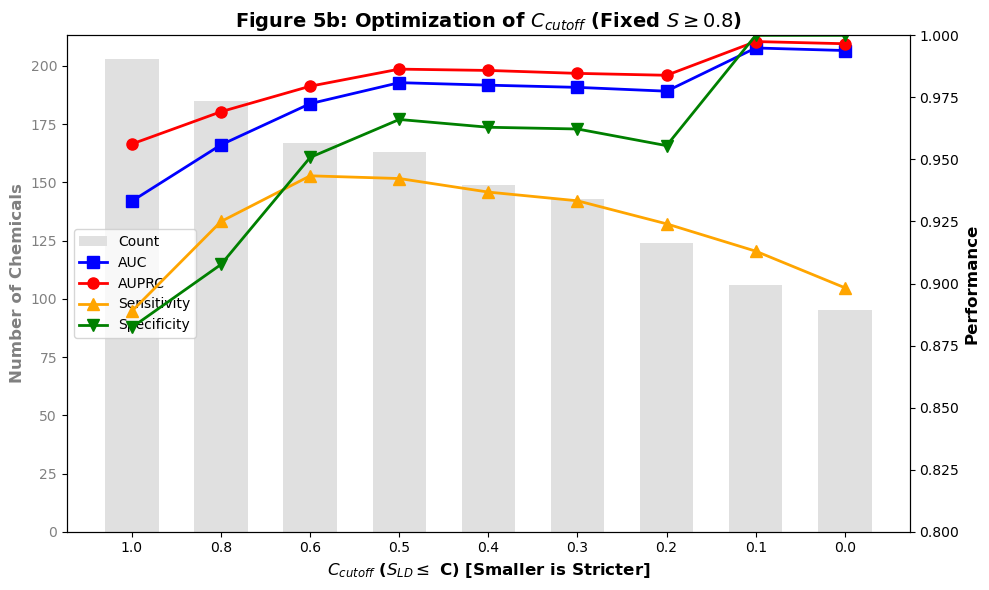

In [6]:
# --- Part B: 优化 C_cutoff ---
FIXED_S = 0.80 # 您可以根据 5a 的结果修改
print(f"选定 S_cutoff = {FIXED_S} 进行第二步...")
df_s_pass = df_ext[df_ext['Max_Sim'] >= FIXED_S].copy()
c_vals = [1.0, 0.8, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.0]
res_b = []
for c in c_vals:
    sub = df_s_pass[df_s_pass['SLD'] <= c]
    m = evaluate_metrics(sub)
    res_b.append({'C_cutoff': c, 'Count': len(sub), 'AUC': m[0], 'AUPRC': m[1], 'Sensitivity': m[2], 'Specificity': m[3]})

plot_fig5(pd.DataFrame(res_b), 'C_cutoff', r'$C_{cutoff}$ ($S_{LD} \leq$ C) [Smaller is Stricter]', 
          f'Figure 5b: Optimization of $C_{{cutoff}}$ (Fixed $S \geq {FIXED_S}$)', 
          y_left_min=0, y_right_min=0.8)

In [17]:
# ==============================================================================
# 6. 构建网络 & 导出 Cytoscape 数据 (修正版 + 仅保留含外部集的社团)
# ==============================================================================
print("\n>>> 步骤 6: 构建网络并导出...")

# 1. 合并用于构图的数据 (Training + External)
# 建议使用 df_s_pass (Sim > FIXED_S) 以减少噪音
df_ext_viz = df_s_pass.copy()
ext_viz_fps = [ext_fps[i] for i in df_s_pass.index]

df_viz = pd.concat([df_train, df_ext_viz], ignore_index=True)
all_fps = train_fps + ext_viz_fps
print(f"   网络节点总数: {len(df_viz)}")

# 2. 构建图
G = nx.Graph()

# 添加节点 (强制类型转换)
for i in range(len(df_viz)):
    row = df_viz.iloc[i]
    G.add_node(i, 
               # 基础属性
               Label_Int=int(row['final_label']),
               Label_Text=str("Active" if row['final_label'] == 1 else "Inactive"),
               Source_Type=str(row['set_type']),
               SLD_Score=float(row['SLD']),
               SMILES=str(row['canon_smiles']),
               
               # Cytoscape 样式映射属性
               Border_Color=str("#0000FF" if row['set_type'] == "External" else "#FFD700"), # 蓝/金
               Fill_Color=str("#D62728" if row['final_label'] == 1 else "#2CA02C")         # 红/绿
              )

# 3. 添加连线
n_total = len(all_fps)
sim_matrix_total = np.zeros((n_total, n_total))
for i in range(n_total):
    sim_matrix_total[i, :] = DataStructs.BulkTanimotoSimilarity(all_fps[i], all_fps)

edge_list = []
for i in range(n_total):
    for j in range(i + 1, n_total):
        if sim_matrix_total[i, j] >= EDGE_CUTOFF:
            # 冲突边标记
            is_conflict = 1 if df_viz.iloc[i]['final_label'] != df_viz.iloc[j]['final_label'] else 0
            edge_list.append((i, j, {"Conflict": is_conflict}))

G.add_edges_from(edge_list)
print(f"   原始图: {G.number_of_nodes()} 节点, {G.number_of_edges()} 边")

# --- 过滤阶段 A: 过滤太小的社团 ---
components = list(nx.connected_components(G))
nodes_to_remove_size = []
for comp in components:
    if len(comp) < MIN_COMMUNITY_SIZE:
        nodes_to_remove_size.extend(list(comp))

G.remove_nodes_from(nodes_to_remove_size)
print(f"   尺寸过滤后 (Size >= {MIN_COMMUNITY_SIZE}): {G.number_of_nodes()} 节点")

# --- 过滤阶段 B: 仅保留含有外部验证集分子的社团 ---
print("   >>> 正在执行内容过滤: 剔除不含 External 分子的社团...")
components = list(nx.connected_components(G)) # 重新获取过滤后的社团
nodes_to_remove_content = []

for comp in components:
    has_external = False
    # 检查该社团中是否有任何一个节点是 External
    for node_id in comp:
        if G.nodes[node_id]['Source_Type'] == 'External':
            has_external = True
            break
    
    # 如果整个社团都没有 External 分子，则标记为移除
    if not has_external:
        nodes_to_remove_content.extend(list(comp))

G.remove_nodes_from(nodes_to_remove_content)
print(f"   内容过滤后 (Must have External): {G.number_of_nodes()} 节点")

# ==============================================================================
# 7. 导出 (Export)
# ==============================================================================
if G.number_of_nodes() > 0:
    # 导出 GraphML
    output_file = "chemical_network_final.graphml"
    nx.write_graphml(G, output_file)
    print(f"✅ [Cytoscape] GraphML 已导出: {output_file}")
    
    # 导出节点属性表 (CSV)
    node_data_list = []
    for n_id, attrs in G.nodes(data=True):
        row_data = {'Node_ID': n_id}
        row_data.update(attrs)
        node_data_list.append(row_data)
    
    pd.DataFrame(node_data_list).to_csv("node_attributes_final.csv", index=False)
    print("✅ [Cytoscape] 属性表已导出: node_attributes_final.csv")
else:
    print("❌ 错误：过滤后无节点。请尝试降低 EDGE_CUTOFF。")

print("\n>>> 全部完成！请使用 Cytoscape 打开 .graphml 文件进行可视化。")


>>> 步骤 6: 构建网络并导出...
   网络节点总数: 9727
   原始图: 9727 节点, 56328 边
   尺寸过滤后 (Size >= 2): 7858 节点
   >>> 正在执行内容过滤: 剔除不含 External 分子的社团...
   内容过滤后 (Must have External): 4368 节点
✅ [Cytoscape] GraphML 已导出: chemical_network_final.graphml
✅ [Cytoscape] 属性表已导出: node_attributes_final.csv

>>> 全部完成！请使用 Cytoscape 打开 .graphml 文件进行可视化。


In [14]:
import pandas as pd
import numpy as np
import os
from rdkit import Chem
from functools import reduce

# ==============================================================================
# 0. 辅助函数
# ==============================================================================
def get_canonical_smiles(smiles):
    """SMILES 标准化"""
    try:
        if pd.isna(smiles): return None
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
    except:
        pass
    return None

def load_dataset_as_column(filepath, col_name_label, is_probe=False):
    """
    读取单个文件，返回包含 [canon_smiles, Original_SMILES, label_column] 的 DataFrame
    """
    if not os.path.exists(filepath):
        print(f"[跳过] 文件不存在: {filepath}")
        return None
    
    try:
        df = pd.read_csv(filepath)
        
        # 1. 提取关键列 & 标签转码
        if is_probe:
            # 探针数据处理
            # 假设列名: Assessment Type, SMILES
            df = df.rename(columns={'SMILES': 'Original_SMILES'})
            df[col_name_label] = df['Assessment Type'].map({'Cancer': 1, 'Noncancer': 0})
        else:
            # Assay 数据处理
            # 假设列名: PUBCHEM_ACTIVITY_OUTCOME, SMILES
            df = df[df['PUBCHEM_ACTIVITY_OUTCOME'].isin(['Active', 'Inactive'])].copy()
            df = df.rename(columns={'SMILES': 'Original_SMILES'})
            df[col_name_label] = df['PUBCHEM_ACTIVITY_OUTCOME'].map({'Active': 1, 'Inactive': 0})
        
        # 2. 计算 Canonical SMILES (合并键)
        df['canon_smiles'] = df['Original_SMILES'].apply(get_canonical_smiles)
        df = df.dropna(subset=['canon_smiles'])
        
        # 3. 去重 (如果同一文件中同一分子出现多次，取最大值/Active优先)
        # 我们同时保留第一条出现的 Original_SMILES 作为代表
        df_dedup = df.groupby('canon_smiles').agg({
            'Original_SMILES': 'first', # 任取一个原始SMILES
            col_name_label: 'max'       # 只要有一次是1，就记为1
        }).reset_index()
        
        return df_dedup
        
    except Exception as e:
        print(f"[错误] 读取 {filepath} 失败: {e}")
        return None

# ==============================================================================
# 1. 批量读取所有数据
# ==============================================================================
print("\n--- 步骤 8: 导出全景活性矩阵 ---")
frames_to_merge = []

# A. 读取 8 个 Assay
assay_files = [
    "AID_1189_datatable_all.csv", "AID_1194_datatable_all.csv", 
    "AID_1199_datatable_all.csv", "AID_1205_datatable_all.csv",
    "AID_1208_datatable_all.csv", "AID_1259407_datatable_all.csv",
    "AID_1259408_datatable_all.csv", "AID_1259411_datatable_all.csv"
]

print("1. 读取 Assay 数据...")
for f in assay_files:
    # 提取 Assay ID (如 AID_1189)
    assay_id = f.split('_datatable')[0] 
    df_temp = load_dataset_as_column(f, assay_id, is_probe=False)
    if df_temp is not None:
        frames_to_merge.append(df_temp)

# B. 读取 Probe 数据
print("2. 读取 Probe 数据...")
probe_file = "probe_data.csv"
if os.path.exists(probe_file):
    df_probe = load_dataset_as_column(probe_file, 'Probe_Label', is_probe=True)
    if df_probe is not None:
        frames_to_merge.append(df_probe)

# ==============================================================================
# 2. 横向合并 (Matrix Construction)
# ==============================================================================
print("3. 正在合并数据矩阵 (Outer Join)...")

if frames_to_merge:
    # 使用 reduce 函数，以 canon_smiles 为键，将所有 DataFrame 横向拼接
    # suffixes 用来处理重复的 Original_SMILES 列名，稍后会合并它们
    df_matrix = reduce(lambda left, right: pd.merge(left, right, on='canon_smiles', how='outer', suffixes=('', '_drop')), frames_to_merge)
    
    # 清理重复的 Original_SMILES 列
    # 逻辑：合并过程中产生了 Original_SMILES, Original_SMILES_drop... 
    # 我们需要把它们合并成一列 'Original_SMILES_Final'
    
    # 找到所有包含 'Original_SMILES' 的列
    os_cols = [c for c in df_matrix.columns if 'Original_SMILES' in c]
    
    # 使用 bfill (后向填充) 将多列合并为一列
    df_matrix['Original_SMILES_Final'] = df_matrix[os_cols].bfill(axis=1).iloc[:, 0]
    
    # 删除多余的中间列
    df_matrix = df_matrix.drop(columns=os_cols)
    
    # ==============================================================================
    # 3. 计算最终标签 (Consensus)
    # ==============================================================================
    # 识别 Assay 列
    assay_cols = [c for c in df_matrix.columns if c.startswith('AID_')]
    
    def calc_consensus(row):
        # 规则 1: 探针优先
        if pd.notna(row.get('Probe_Label')):
            return int(row['Probe_Label']), 'Probe'
        
        # 规则 2: Assay 平均
        vals = [row[c] for c in assay_cols if pd.notna(row[c])]
        if vals:
            mean_val = sum(vals) / len(vals)
            # >= 0.5 判为 1
            return (1 if mean_val >= 0.5 else 0), 'Assay_Consensus'
        
        return None, None

    # 应用计算
    consensus_res = df_matrix.apply(calc_consensus, axis=1)
    df_matrix[['Final_Label', 'Source_Type']] = pd.DataFrame(consensus_res.tolist(), index=df_matrix.index)
    
    # 过滤掉无法计算标签的行
    df_matrix = df_matrix.dropna(subset=['Final_Label'])
    df_matrix['Final_Label'] = df_matrix['Final_Label'].astype(int)

    # ==============================================================================
    # 4. 导出 CSV
    # ==============================================================================
    # 调整列顺序，好看一点
    cols_order = ['Original_SMILES_Final', 'canon_smiles', 'Final_Label', 'Source_Type', 'Probe_Label'] + assay_cols
    # 仅保留存在的列
    cols_order = [c for c in cols_order if c in df_matrix.columns]
    
    df_final_export = df_matrix[cols_order]
    df_final_export = df_final_export.rename(columns={'Original_SMILES_Final': 'Original_SMILES'})
    
    output_filename = "all_compounds_9_datasets_activity.csv"
    df_final_export.to_csv(output_filename, index=False)
    
    print("-" * 40)
    print(f"✅ 导出成功: {output_filename}")
    print(f"   总化合物数: {len(df_final_export)}")
    print(f"   包含列: {list(df_final_export.columns)}")
    print("\n   [前 3 行预览]:")
    print(df_final_export.head(3))
    
else:
    print("❌ 错误：没有数据可合并。")


--- 步骤 8: 导出全景活性矩阵 ---
1. 读取 Assay 数据...


[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:07] WARNING: not removing hydrogen atom without neighbors
[01:18:13] WARNING: not removing hydrogen atom without neighbors
[01:18:13] WARNING: not removing hydrogen atom without neighbors
[01:18:13] WARNING: not removing hydrogen atom without neighbors
[01:18:13] WARNING: not r

2. 读取 Probe 数据...
3. 正在合并数据矩阵 (Outer Join)...
----------------------------------------
✅ 导出成功: all_compounds_9_datasets_activity.csv
   总化合物数: 9524
   包含列: ['Original_SMILES', 'canon_smiles', 'Final_Label', 'Source_Type', 'Probe_Label', 'AID_1189', 'AID_1194', 'AID_1199', 'AID_1205', 'AID_1208', 'AID_1259407', 'AID_1259408', 'AID_1259411']

   [前 3 行预览]:
                                     Original_SMILES  \
0  CN1[C@@H]2CC(C[C@H]1[C@H]3[C@@H]2O3)OC(=O)[C@@...   
1                                        C(Br)(Br)Br   
2                                           C(CBr)Br   

                                     canon_smiles  Final_Label  \
0  Br.CN1C2CC(OC(=O)C(CO)c3ccccc3)CC1C1OC12.O.O.O            0   
1                                       BrC(Br)Br            1   
2                                          BrCCBr            1   

       Source_Type  Probe_Label  AID_1189  AID_1194  AID_1199  AID_1205  \
0  Assay_Consensus          NaN       0.0       0.0       0.0       0.0   
1  

In [15]:
import pandas as pd
import os
from rdkit import Chem

# ==============================================================================
# 0. 定义 SMILES 标准化函数
# ==============================================================================
def get_canonical_smiles(smiles):
    """将 SMILES 转换为标准化的 Canonical SMILES"""
    try:
        if pd.isna(smiles): return None
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            # isomericSmiles=False: 忽略手性差异以增加通用匹配率
            # 如果您的研究严格区分手性，请改为 True
            return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)
    except:
        pass
    return None

# ==============================================================================
# 1. 处理外部验证集并导出
# ==============================================================================
print("--- 正在处理外部验证集 (标准化导出) ---")

ext_file = "external_data.csv" # 请确保文件名与您本地一致 (注意空格)
output_filename = "external_validation_standardized.csv"

if os.path.exists(ext_file):
    # 1. 读取数据
    df_ext = pd.read_csv(ext_file)
    print(f"原始数据读取成功，共 {len(df_ext)} 行。")
    
    # 2. 生成标准化 SMILES 列
    # 假设原始 SMILES 列名为 'smiles' (根据您之前的描述)
    if 'smiles' in df_ext.columns:
        print("正在计算 Canonical SMILES...")
        df_ext['canon_smiles'] = df_ext['smiles'].apply(get_canonical_smiles)
        
        # 3. 过滤无效分子 (可选，为了保证数据质量建议保留)
        # 如果您想保留那些转换失败的行以便检查，可以注释掉下面这行
        df_ext_clean = df_ext.dropna(subset=['canon_smiles']).copy()
        
        # 4. 调整列顺序 (把 canon_smiles 放在前面方便看)
        cols = ['smiles', 'canon_smiles'] + [c for c in df_ext_clean.columns if c not in ['smiles', 'canon_smiles']]
        df_final = df_ext_clean[cols]
        
        # 5. 导出
        df_final.to_csv(output_filename, index=False)
        
        print("-" * 40)
        print(f"✅ 导出成功！文件已保存为: {output_filename}")
        print(f"有效化合物数: {len(df_final)}")
        print("\n[前 5 行预览]:")
        print(df_final.head())
        
    else:
        print("❌ 错误：输入文件中找不到 'smiles' 列，请检查列名。")
else:
    print(f"❌ 错误：找不到文件 {ext_file}。")

--- 正在处理外部验证集 (标准化导出) ---
原始数据读取成功，共 212 行。
正在计算 Canonical SMILES...
----------------------------------------
✅ 导出成功！文件已保存为: external_validation_standardized.csv
有效化合物数: 212

[前 5 行预览]:
                                              smiles  \
0  [O-][N+](=O)C([N+](=O)[O-])([N+](=O)[O-])[N+](...   
1                    [O-][N+](=O)c1ccc(o1)c1nnc(s1)N   
2                  [O-][N+](=O)c1ccc2c(c1)Cc1c2cccc1   
3                     [O-][N+](=O)c1ccc2c3c1cccc3CC2   
4                         [O-][N+](=O)c1cccc2c1cccc2   

                                        canon_smiles  Unnamed: 0  pred_prob  \
0  O=[N+]([O-])C([N+](=O)[O-])([N+](=O)[O-])[N+](...           0   0.742188   
1                   Nc1nnc(-c2ccc([N+](=O)[O-])o2)s1           1   0.876822   
2                 O=[N+]([O-])c1ccc2c(c1)Cc1ccccc1-2           2   0.825600   
3                   O=[N+]([O-])c1ccc2c3c(cccc13)CC2           3   0.870900   
4                         O=[N+]([O-])c1cccc2ccccc12           4   0.603662   

  